In [1]:
from shapely import geometry
from pystac_client import Client
import geopandas as gpd
from distributed import LocalCluster
import matplotlib.pyplot as plt

import pandas as pd
import xarray as xr
import zarr
import dask.array as da


### Own modules
from modules.utils import to_km2, plot_rgb_ndvi
from modules.data_load import get_epsg_from_first_band, load_sentinel_data, load_sentinel_scl, validate_scl

In [2]:
START_YEAR = 2015
END_YEAR = 2026

Setup


In [3]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
#bbox = harz_boundaries.geometry.values[0].bounds
bbox = [10.563869,51.773247,10.672531,51.832339]


bbox_polygon = geometry.box(*bbox)
polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])


catalog = Client.open("https://stac.core.eopf.eodc.eu")

C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 56136 instead
  warnings.warn(


CloudCover is in properties, so we can select it from here.

In [4]:
years = range(START_YEAR, END_YEAR)


r10m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_10m",
    max_cloud_cover=30
)
r10m

2018: selected item with cloud cover = 0.42824%
2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%


C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250930T102739_N0511_R108_T32UPC_20250930T142814' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250930T102739_N0511_R108_T32UNC_20250930T142814' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250831T102559_N0511_R108_T32UPC_20250831T143825' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2A_MSIL2A_20250825T101701_N0511_R065_T32UPC_20250825T142615' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250821T102559_N0511_R108_T32UPC_20250821T125116' is deprecate

2025: selected item with cloud cover = 0.00205%


<xarray.Dataset> Size: 23GB
Dimensions:      (time: 6, y: 10980, x: 10980)
Coordinates:
  * time         (time) datetime64[ns] 48B 2018-07-24T10:30:21.024000 ... 202...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 88kB 600005 600015 600025 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [5]:

r20m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_20m",
    max_cloud_cover=30
)
r20m

2018: selected item with cloud cover = 0.42824%
2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%


C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250930T102739_N0511_R108_T32UPC_20250930T142814' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250930T102739_N0511_R108_T32UNC_20250930T142814' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250831T102559_N0511_R108_T32UPC_20250831T143825' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2A_MSIL2A_20250825T101701_N0511_R065_T32UPC_20250825T142615' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250821T102559_N0511_R108_T32UPC_20250821T125116' is deprecate

2025: selected item with cloud cover = 0.00205%


<xarray.Dataset> Size: 14GB
Dimensions:      (time: 6, y: 5490, x: 5490)
Coordinates:
  * time         (time) datetime64[ns] 48B 2018-07-24T10:30:21.024000 ... 202...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 44kB 600010 600030 600050 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [6]:
scl20m = load_sentinel_scl(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SCL_20m",
    max_cloud_cover=30
)
scl20m

2018: selected item with cloud cover = 0.42824%
2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%


C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250930T102739_N0511_R108_T32UPC_20250930T142814' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250930T102739_N0511_R108_T32UNC_20250930T142814' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250831T102559_N0511_R108_T32UPC_20250831T143825' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2A_MSIL2A_20250825T101701_N0511_R065_T32UPC_20250825T142615' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250821T102559_N0511_R108_T32UPC_20250821T125116' is deprecate

2025: selected item with cloud cover = 0.00205%


<xarray.Dataset> Size: 181MB
Dimensions:  (time: 6, y: 5490, x: 5490)
Coordinates:
  * time     (time) datetime64[ns] 48B 2018-07-24T10:30:21.024000 ... 2023-06...
Dimensions without coordinates: y, x
Data variables:
    scl      (time, y, x) uint8 181MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [7]:
epsg = get_epsg_from_first_band(r10m)

bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels


Problem: Maybe the data we are using is obstructed by clouds e.g. and is being thrown out of the Mask?

#H2
WIP

In [8]:
from zarr.errors import PathNotFoundError

## TODO: SCL Drop anything, but forest in the SCL Classification
def get_item_for_year(year):
    results = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=[f"{year}-06-01", f"{year}-08-30"],
        query={"eo:cloud_cover": {"lt": 30}},  # optional filter
    )
    items = results.item_collection()
    if not items:
        return None

    # pick least cloudy item to get better images.
    best_item = min(items, key=lambda x: x.properties.get("eo:cloud_cover", 999))

    print(f"{year}: selected item with cloud cover = {best_item.properties.get("eo:cloud_cover", "unknown")}%")

    return best_item

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
scl_datasets = []



for item in items:
    try:
        href = item.assets["SCL_20m"].href

        # Explicit guard for empty / missing paths
        if not href:
            raise PathNotFoundError("Empty SCL_20m href")

        scl_z = zarr.open(href, mode="r")

        # Convert Zarr array to xarray DataArray
        scl_da = xr.DataArray(
            scl_z,
            dims=("y", "x"),  # adjust if your dimensions differ
            name="SCL",
        )

    except (PathNotFoundError, FileNotFoundError, OSError, KeyError, ValueError):
        # Optional logging:
        # print(f"Skipping missing SCL_20m asset for item {item.id}")
        continue

    # Add time dimension
    scl_da = scl_da.expand_dims(
        time=[pd.to_datetime(item.datetime).tz_localize(None)]
    )

    scl_datasets.append(scl_da)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
scl20m = xr.concat(scl_datasets, dim="time", join="outer")
scl20m

2018: selected item with cloud cover = 0.42824%
2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%


C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2A_MSIL2A_20250825T101701_N0511_R065_T32UPC_20250825T142615' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250821T102559_N0511_R108_T32UPC_20250821T125116' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2A_MSIL2A_20250818T103041_N0511_R108_T32UPC_20250818T143613' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2A_MSIL2A_20250818T103041_N0511_R108_T32UNC_20250818T143613' is deprecated.
  warnings.warn(
C:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\pystac\item.py:481: DeprecatedWarning: The item 'S2B_MSIL2A_20250818T101559_N0511_R065_T32UPC_20250818T142332' is deprecate

2025: selected item with cloud cover = 0.00205%


<xarray.DataArray 'SCL' (time: 6, y: 5490, x: 5490)> Size: 181MB
array([[[5, 5, 5, ..., 0, 0, 0],
        [5, 5, 5, ..., 0, 0, 0],
        [5, 5, 5, ..., 0, 0, 0],
        ...,
        [5, 5, 5, ..., 0, 0, 0],
        [5, 5, 5, ..., 0, 0, 0],
        [5, 5, 5, ..., 0, 0, 0]],

       [[4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        ...,
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0]],

       [[4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        ...,
...
        ...,
        [5, 5, 5, ..., 0, 0, 0],
        [5, 5, 5, ..., 0, 0, 0],
        [5, 5, 5, ..., 0, 0, 0]],

       [[4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        ...,
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0]],

       [[5, 5, 5, ..., 4, 4, 4],
        [5, 5, 5, ..., 4, 4, 4],
        [5, 5, 5, ..., 4, 4, 4],
        ...,
        [4, 4, 4, ..., 5, 5, 5],
        [4, 4, 4, ..., 5, 5, 4],
        [4, 4, 4, ..., 5, 4, 5]]], shape=(6, 5490, 5490), dtype=uint8)
Coordinates:
  * time     (time) datetime64[ns] 48B 2018-07-24T10:30:21.024000 ... 2023-06...
Dimensions without coordinates: y, x
Attributes: (7)

In [9]:

r10m

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 6, y: 10980, x: 10980)
Coordinates:
  * time         (time) datetime64[ns] 48B 2018-07-24T10:30:21.024000 ... 202...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 88kB 600005 600015 600025 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [10]:
#mask_ratio = (~valid_mask).sum() / valid_mask.size
#print(f"Fraction of pixels masked: {mask_ratio.values:.2%}") #TODO: Masking not working correctly, so we are skippig that. Currently, mask is all true, which can't really be correct.

Result: Too little pixels removed for it to mess up the data that much.


In [11]:
from datetime import datetime

# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??
reflectances_r10m = r10m

reflectances_r10m["ndvi"] = (reflectances_r10m.b08 - reflectances_r10m.b04) / (reflectances_r10m.b08 + reflectances_r10m.b04)

#TODO: Take EPSG from satellite data
#TODO: Check, whether every offset and scale matches.

cloudless_bands_ndvi = reflectances_r10m.sel(
    time=datetime(2018, 6, 4), method="nearest"
)

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)

ndvi_region = region["ndvi"].compute()

yearly_ds = (
    reflectances_r10m.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)
yearly_ds

<xarray.Dataset> Size: 123MB
Dimensions:      (year: 6, y: 673, x: 764)
Coordinates:
  * year         (year) int64 48B 2018 2019 2020 2021 2022 2023
  * y            (y) int64 5kB 5743705 5743695 5743685 ... 5736995 5736985
  * x            (x) int64 6kB 607765 607775 607785 ... 615375 615385 615395
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 25MB dask.array<chunksize=(1, 673, 764), meta=np.ndarray>
    b03          (year, y, x) float64 25MB dask.array<chunksize=(1, 673, 764), meta=np.ndarray>
    b04          (year, y, x) float64 25MB dask.array<chunksize=(1, 673, 764), meta=np.ndarray>
    b08          (year, y, x) float64 25MB dask.array<chunksize=(1, 673, 764), meta=np.ndarray>
    ndvi         (year, y, x) float64 25MB dask.array<chunksize=(1, 673, 764), meta=np.ndarray>

In [12]:
#NDVI for selected region, seems to be more optimal than before.
ndvi_region.min().item(), ndvi_region.max().item(), ndvi_region.mean().item()

(-0.20797720797720806, 0.9350237717908083, 0.7303790704358227)

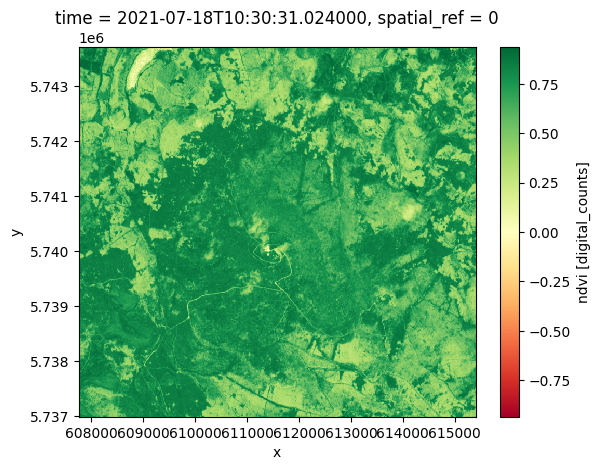

In [13]:
reflectances_r10m.ndvi.isel(time=3).sel(x=x_slice, y=y_slice).plot(
    cmap="RdYlGn"
)

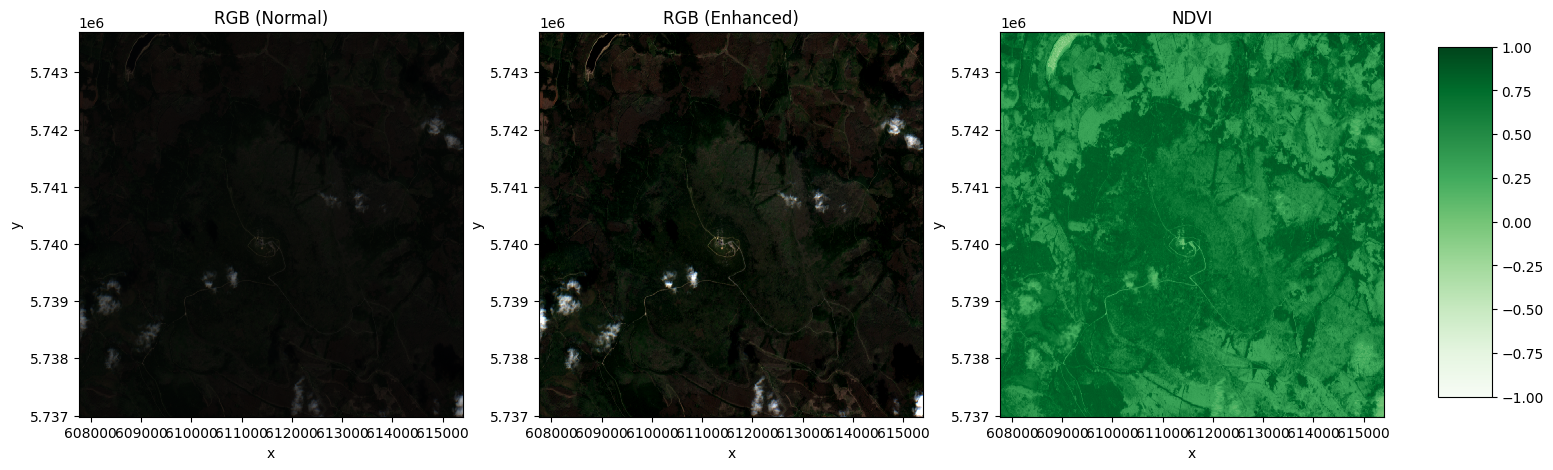

In [14]:
year = 2020
region = yearly_ds.sel(year=year)

plot_rgb_ndvi(region, x_slice, y_slice)

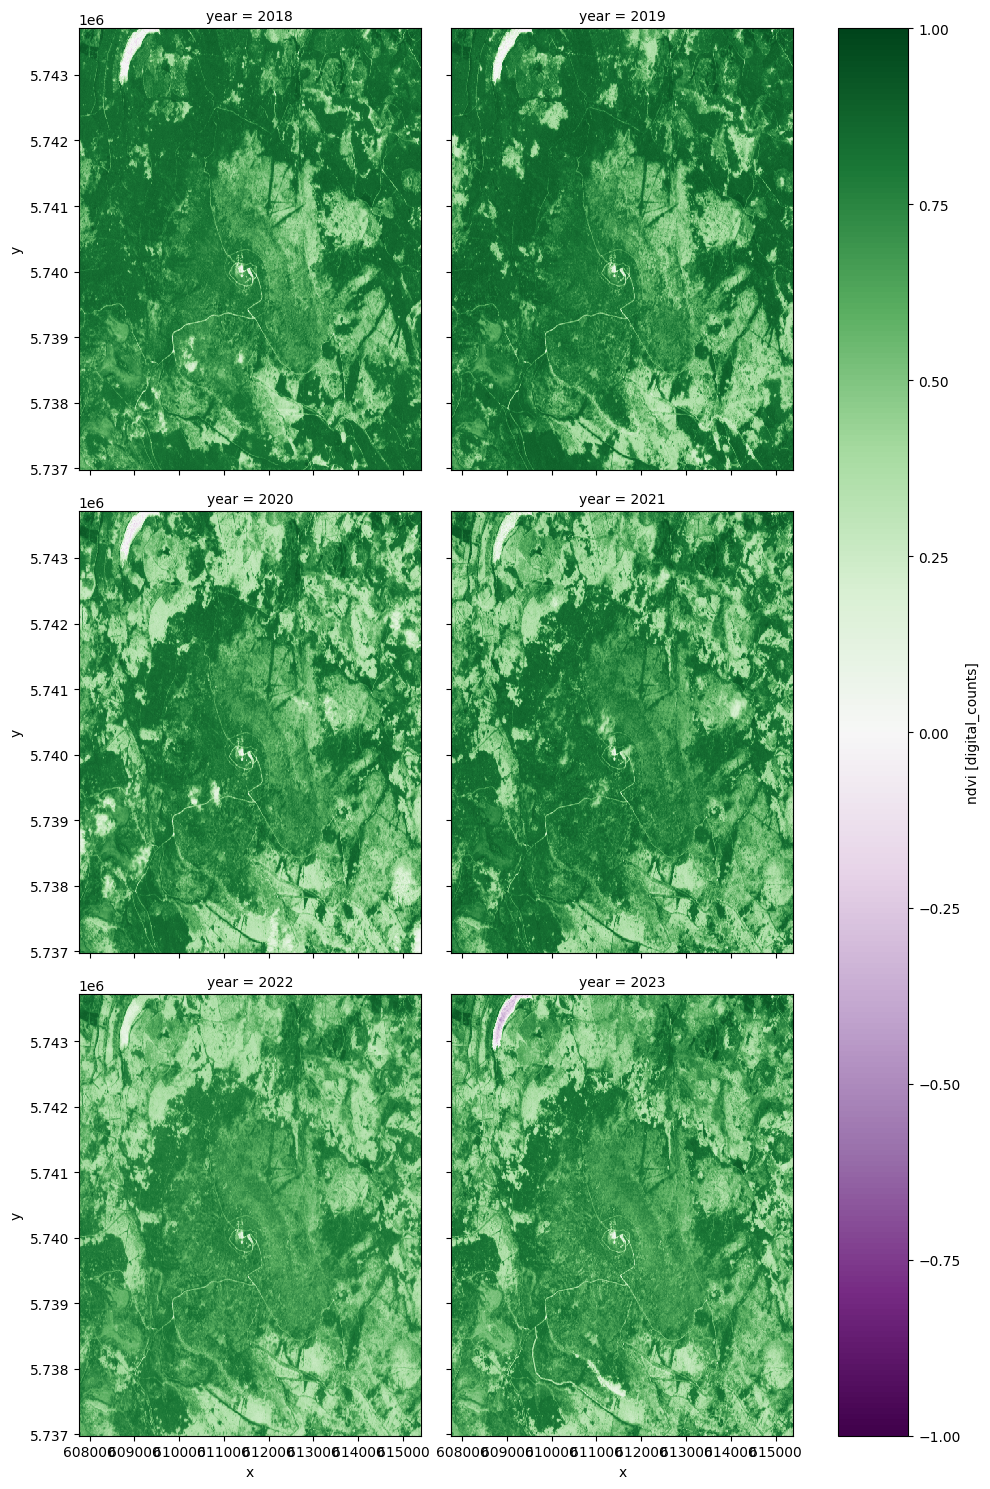

In [15]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=slice(START_YEAR, END_YEAR)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [16]:
yearly_ds.ndvi.load()
yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7


#TODO: Remove resolution variable in favor of slice-size
resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)

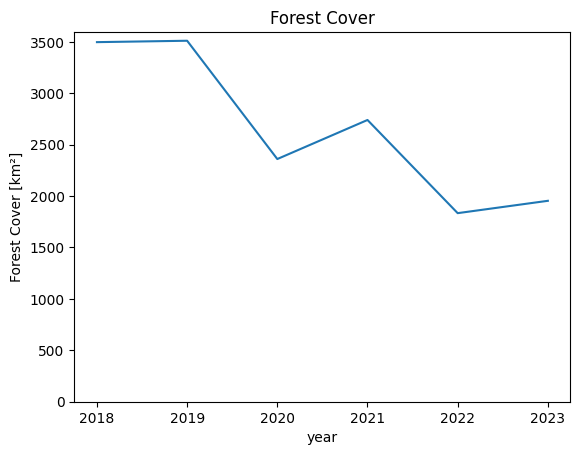

In [17]:
forest_area_km2.load() #Lazy loading
forest_area_km2.plot()


#TODO: Change tracking, show difference in marginality
plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

# Variance Computing for detecting monoculture

In [18]:
#Basic NDVI-Variance


ndvi = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=2021)

ndvi_var = (
    ndvi
    .rolling(x=5, y=5, center=True)
    .var()
)
ndvi_mean = (
    ndvi
    .rolling(x=5, y=5, center=True)
    .mean()
)

ndvi_cv = ndvi_var / ndvi_mean #Normalized with mean


#TODO: Aggregate over time? Probably even get better results in winter, because the trees might not be obstructing? What would we take then instead of NDVI? --> Take more than one image.


monoculture_mask = ndvi_cv < 0.05 #Example


#Different Windows to get a better view on uniformity

cv_3 = ndvi.rolling(x=3, y=3, center=True).var() / ndvi.rolling(x=3, y=3, center=True).mean()
cv_7 = ndvi.rolling(x=7, y=7, center=True).var() / ndvi.rolling(x=7, y=7, center=True).mean()

cv_combined = (cv_3 + cv_7) / 2
cv_combined

<xarray.DataArray 'ndvi' (y: 673, x: 764)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(673, 764))
Coordinates:
  * y            (y) int64 5kB 5743705 5743695 5743685 ... 5736995 5736985
  * x            (x) int64 6kB 607765 607775 607785 ... 615375 615385 615395
    spatial_ref  int64 8B 0
    year         int64 8B 2021
Attributes: (12)

In [19]:
total_pixels = cv_combined.size
nan_pixels = cv_combined.isnull().sum().item()
nan_percentage = (nan_pixels / total_pixels) * 100

print(
    f"NaN percentage in cv_combined: {nan_percentage:.2f}% "
    f"({nan_pixels} out of {total_pixels} pixels). "
)

NaN percentage in cv_combined: 1.67% (8586 out of 514172 pixels). 


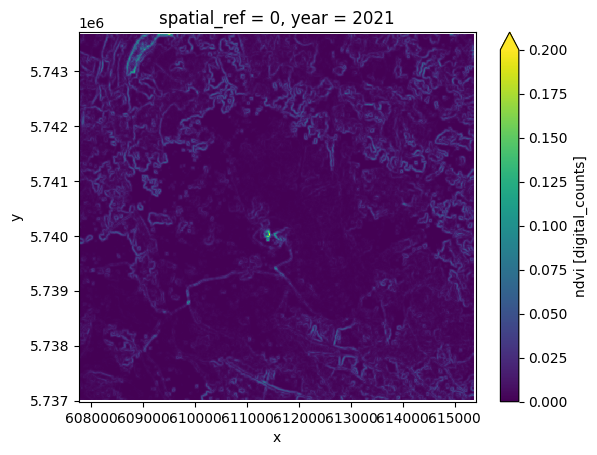

In [20]:
cv_combined.plot(
    cmap="viridis",
    vmin=0,
    vmax=0.2
)

# HIGH: High Variance, so less monoculture.
# LOW: Low Variance, so more monoculture.
# TODO: Add this to a bounding box that is entirely forest for clearer visibility.
# TODO: Create a bounding box in QGIS for areas with majority pure forests.

Monoculture Detection

In [21]:
import numpy as np

# Remove everything but Forest
forest_ds = yearly_ds


In [22]:
# Band ratios (species-sensitive)
nir_red = forest_ds.b08 / forest_ds.b04
green_red = forest_ds.b03 / forest_ds.b04

nir_red_texture = nir_red.mean("year").rolling(
    x=3, y=3, center=True
).var()


In [23]:
import numpy as np

#Multi-band spectral entropy

bands = forest_ds[["b02", "b03", "b04", "b08"]]
spectral = bands.to_array("band")

# normalize
spectral_norm = spectral / spectral.sum("band")

entropy = -(spectral_norm * np.log(spectral_norm)).sum("band")
entropy_mean = entropy.mean("year")


In [24]:
#Forest Monoculture will be "flat"
ndvi_texture = forest_ds.ndvi.mean("year").rolling(
    x=3, y=3, center=True
).std()

In [25]:
spectral_std = spectral.mean("year").rolling(
    x=3, y=3, center=True
).std().mean("band")

In [26]:
# Forest Monoculture index
# TODO: Find a paper to get background on this? Or some knowledge?

forest_mono_index = (
    (1 - spectral_std / spectral_std.max()) * 0.4 +
    (1 - entropy_mean / entropy_mean.max()) * 0.3 +
    (1 - ndvi_texture / ndvi_texture.max()) * 0.3
)

forest_monoculture = forest_mono_index > 0.75 # Rough idea, what could be considered monoculture and what not?


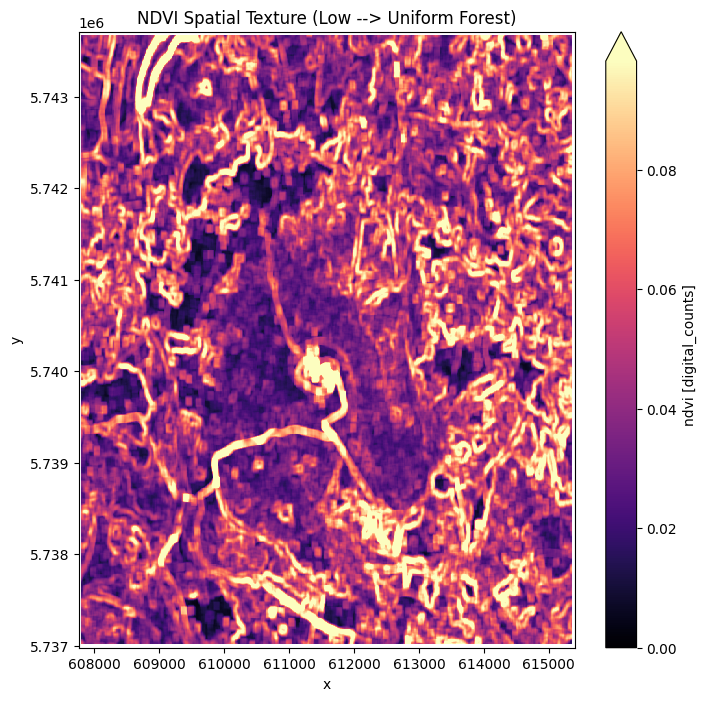

In [28]:
ndvi_texture = yearly_ds.ndvi.mean("year").rolling(
    x=9, y=9, center=True
).std()

ndvi_texture.plot(
    figsize=(8, 8),
    cmap="magma",
    vmin=0,
    vmax=ndvi_texture.quantile(0.95)
)
plt.title("NDVI Spatial Texture (Low --> Uniform Forest)")
plt.show()


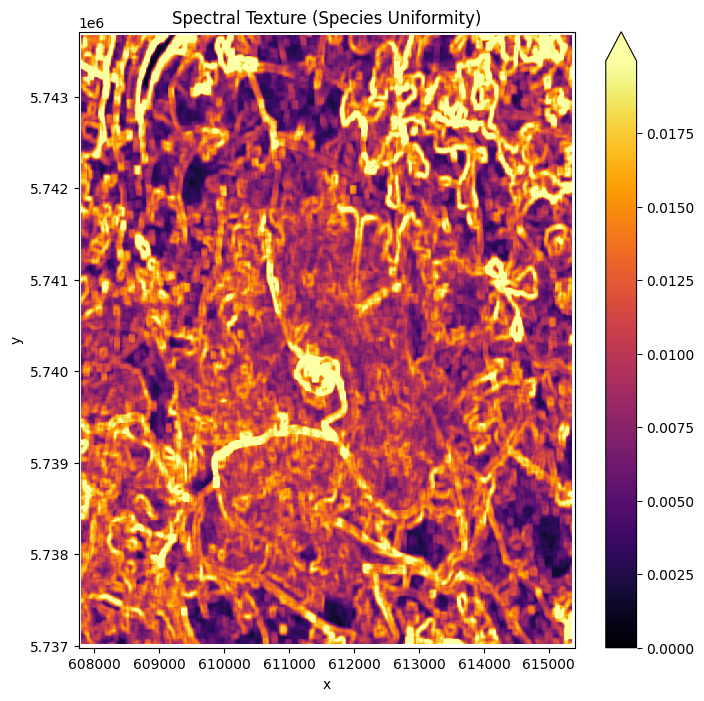

In [29]:
bands = yearly_ds[["b02", "b03", "b04", "b08"]]
spectral = bands.to_array("band").mean("year")

spectral_texture = spectral.rolling(
    x=9, y=9, center=True
).std().mean("band")

vmax = spectral_texture.quantile(0.95).compute()

spectral_texture.plot(
    figsize=(8, 8),
    cmap="inferno",
    vmin=0,
    vmax=vmax
)
plt.title("Spectral Texture (Species Uniformity)")
plt.show()

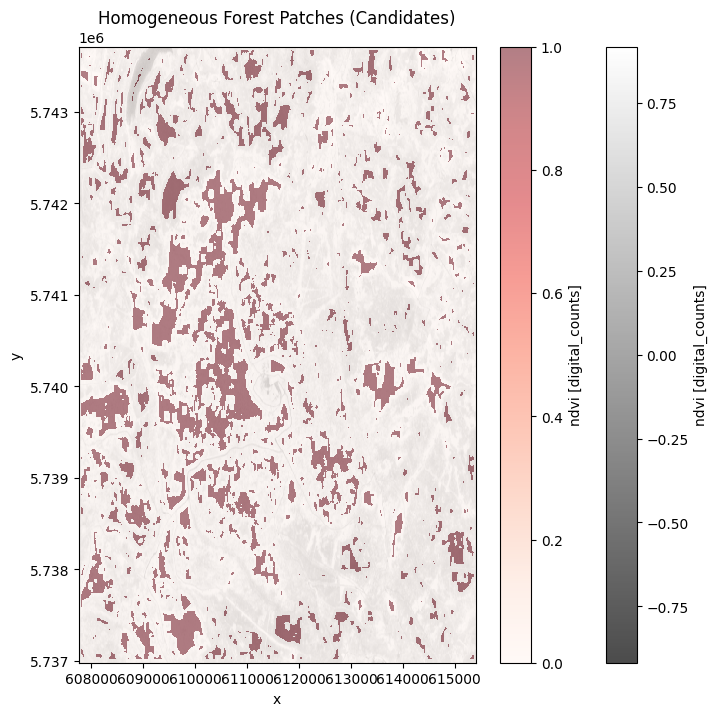

In [30]:
mono_candidate = ndvi_texture < ndvi_texture.quantile(0.15)

plt.figure(figsize=(8, 8))
yearly_ds.ndvi.mean("year").plot(cmap="gray", alpha=0.7)
mono_candidate.plot(
    cmap="Reds",
    alpha=0.5
)
plt.title("Homogeneous Forest Patches (Candidates)")
plt.show()

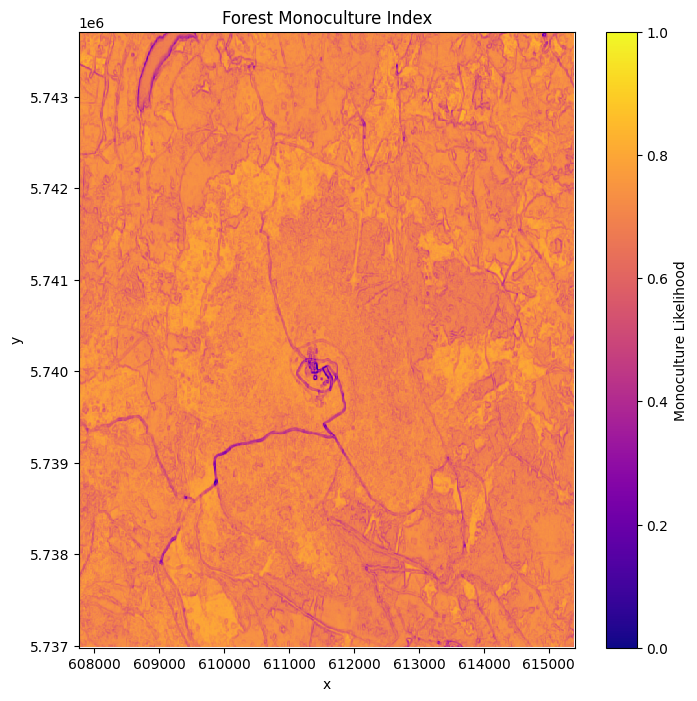

In [31]:
forest_mono_index.plot(
    figsize=(8, 8),
    cmap="plasma",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Monoculture Likelihood"}
)
plt.title("Forest Monoculture Index")
plt.show()

# Last solution, but we somehow have to get rid of the streets and cities.


Mask the roads simply.


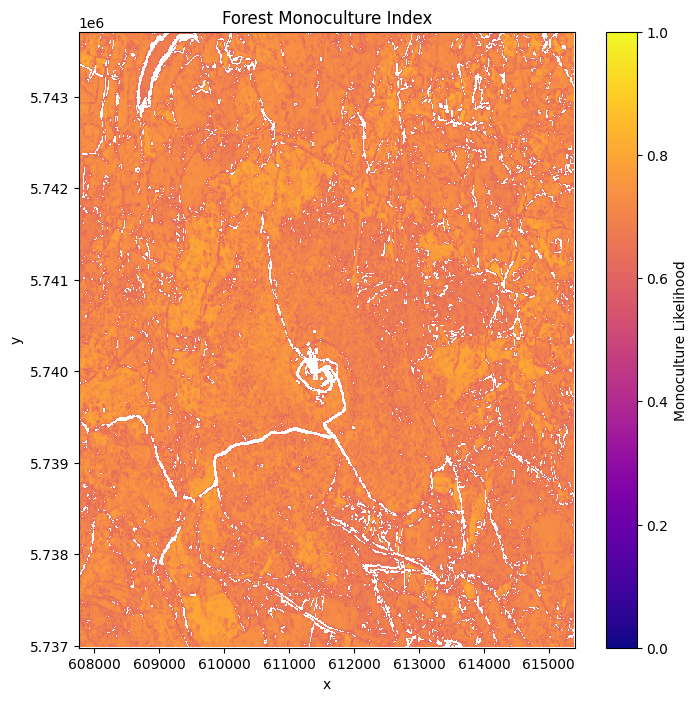

In [38]:
cutoff = 0.6 #Has to be defined by hand, because we can't automate what we see. Maybe it would be possibly, if we look at the density --> Technically these are outliers.
forest_only = forest_mono_index.where(forest_mono_index >= cutoff)

forest_only.plot(
    figsize=(8, 8),
    cmap="plasma",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Monoculture Likelihood"}
)
plt.title("Forest Monoculture Index")
plt.show()


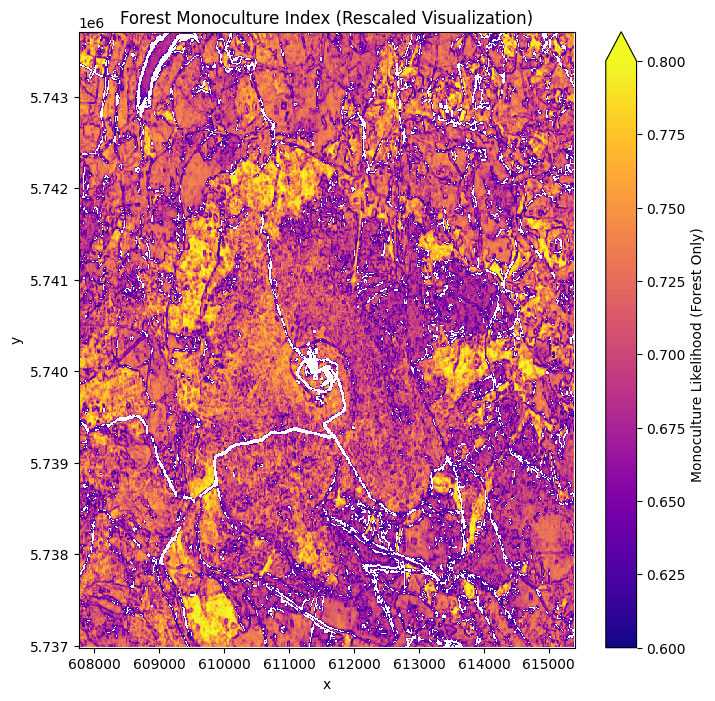

In [39]:
# Rescaling, so it fits the overall scale a bit better.
# TODO: make vmax a variable.
forest_only.plot(
    figsize=(8, 8),
    cmap="plasma",
    vmin=cutoff,
    vmax=0.8,
    cbar_kwargs={"label": "Monoculture Likelihood (Forest Only)"}
)
plt.title("Forest Monoculture Index (Rescaled Visualization)")
plt.show()


Nice! We can actually even see here, now with the rescaling, that there are patches of forest, which are more likely to be monoculture.

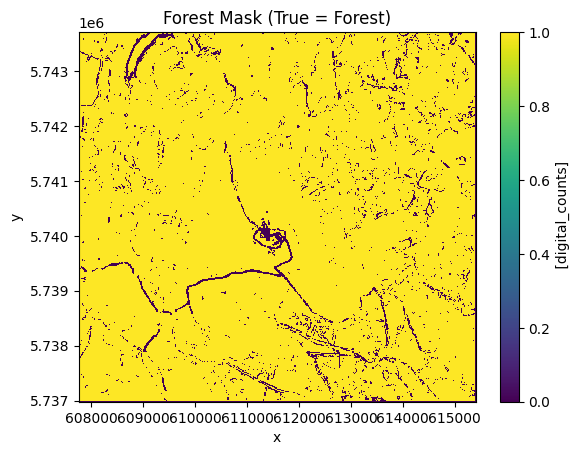

In [34]:
# Would be nice to get a mask that ignores roads and human built structures.
forest_mask = forest_only.notnull()

# Plotting the mask
forest_mask.plot()
plt.title("Forest Mask (True = Forest)")
plt.show()

# Use mask on other datasets like this.
ndvi_forest_masked = ndvi.where(forest_mask)



Sanity check: Pathways are shown as extremely monoculture likely, so that checks out.
TODO: Remove these pixels with a mask?


In [35]:
# TODO: Make the data functions.

TODO: Rather take this bounding box --> Identify relevant years to compare from the deforestation-3 --> Compare two years with each other.
TODO: Cleanup functions.
TODO: Change it from a rolling function over all years (to limit the effect of clouds) to two relevant years, and compare these two.


In [36]:

#TODO: Compare the area through the years with this visualization. --> Might be clouds?
#TODO: Check from before 2015, maybe? How can we validate that there is monoculture --> Check before, and at the maximum of forest loss? Compare these two ways then.
#TODO: Do this mean()-Thing for getting a masked data with unmasked values for forest before 2015, and then compare to the worst point of forest loss and see which survived!
# TODO: Add another satellite data from a different satellite.